#LOCACIONES DONDE SE ESTÁ HACIENDO MODELIZACIÓN CLIMÁTICA

In [1]:
# =============================================================================
# BLOQUE 1: IMPORTACIÓN Y CONFIGURACIÓN DE PLOTLY
# =============================================================================
# Instalar librerías si es necesario (descomentar en Colab)
!pip install plotly pandas kaleido

import pandas as pd
import plotly.express as px
import plotly.io as pio

# CONFIGURACIÓN CRÍTICA DEL RENDERER - ¡Esto soluciona el problema!
# Detectar entorno y configurar el renderer apropiado
import sys
if 'google.colab' in sys.modules:
    pio.renderers.default = 'colab'  # Para Google Colab
elif 'VSCODE' in str(sys.argv):
    pio.renderers.default = 'vscode'  # Para VS Code
else:
    pio.renderers.default = 'notebook'  # Para Jupyter Notebook tradicional

# =============================================================================
# BLOQUE 2: CREACIÓN DE DATOS SINTÉTICOS
# =============================================================================

data = {
    'country': [
        'United States', 'United Kingdom', 'Germany', 'France', 'Japan',
        'China', 'Canada', 'Australia', 'Russia', 'Italy',
        'Spain', 'Netherlands', 'Norway', 'Sweden', 'India',
        'South Korea', 'Brazil', 'Argentina', 'South Africa', 'Mexico',
        'Switzerland', 'Belgium', 'Austria', 'Denmark', 'Finland',
        'Poland', 'Turkey', 'Egypt', 'Nigeria', 'Kenya'
    ],
    'iso3': [
        'USA', 'GBR', 'DEU', 'FRA', 'JPN',
        'CHN', 'CAN', 'AUS', 'RUS', 'ITA',
        'ESP', 'NLD', 'NOR', 'SWE', 'IND',
        'KOR', 'BRA', 'ARG', 'ZAF', 'MEX',
        'CHE', 'BEL', 'AUT', 'DNK', 'FIN',
        'POL', 'TUR', 'EGY', 'NGA', 'KEN'
    ],
    'cmip6_institutions': [
        5, 3, 3, 2, 3,
        4, 2, 2, 2, 2,
        2, 2, 1, 1, 2,
        2, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 0, 0, 0
    ],
    'publications_2020_2025': [
        2800, 1200, 1100, 950, 1300,
        2200, 650, 580, 420, 520,
        480, 410, 320, 290, 680,
        590, 310, 180, 150, 220,
        380, 340, 210, 240, 200,
        280, 190, 85, 60, 75
    ],
    'avg_citations': [
        42, 45, 43, 41, 38,
        35, 40, 39, 32, 37,
        36, 44, 46, 45, 28,
        33, 30, 26, 24, 27,
        47, 42, 38, 43, 41,
        31, 29, 22, 19, 21
    ]
}

df = pd.DataFrame(data)

# =============================================================================
# BLOQUE 3: CÁLCULO DEL ÍNDICE COMPUESTO
# =============================================================================

def min_max_normalize(series, min_val=0, max_val=100):
    """Normaliza una serie a escala [min_val, max_val]"""
    min_s = series.min()
    max_s = series.max()
    if max_s == min_s:
        return pd.Series([50] * len(series))
    return ((series - min_s) / (max_s - min_s)) * (max_val - min_val) + min_val

df['inst_norm'] = min_max_normalize(df['cmip6_institutions'])
df['pub_norm'] = min_max_normalize(df['publications_2020_2025'])
df['cite_norm'] = min_max_normalize(df['avg_citations'])

weights = {'inst': 0.4, 'pub': 0.3, 'cite': 0.3}
df['composite_index'] = (
    weights['inst'] * df['inst_norm'] +
    weights['pub'] * df['pub_norm'] +
    weights['cite'] * df['cite_norm']
).round(2)

# =============================================================================
# BLOQUE 4: PREPARACIÓN DE HOVER DATA
# =============================================================================

df['hover_text'] = df.apply(lambda row: f"""
<b>{row['country']}</b><br>
🏛️ Instituciones CMIP6: {row['cmip6_institutions']}<br>
📄 Publicaciones (2020-2025): {row['publications_2020_2025']:,}<br>
🔖 Citas promedio: {row['avg_citations']:.1f}<br>
📊 Índice Compuesto: <b>{row['composite_index']:.2f}/100</b>
""", axis=1)

# =============================================================================
# BLOQUE 5: GENERACIÓN DEL MAPA COROPLÉTICO
# =============================================================================

fig = px.choropleth(
    df,
    locations='iso3',
    color='composite_index',
    hover_name='country',
    hover_data={'iso3': False, 'hover_text': True},
    color_continuous_scale='Viridis',
    range_color=(0, 100),
    title='<b>Índice Compuesto de Capacidad de Modelización Climática (2020-2025)</b><br><sup>Basado en: Instituciones CMIP6 (40%) + Publicaciones (30%) + Impacto (30%)</sup>',
    labels={'composite_index': 'Índice de Capacidad<br>(0-100)'}
)

# =============================================================================
# BLOQUE 6: PERSONALIZACIÓN ESTÉTICA
# =============================================================================

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='rgba(0,0,0,0.3)',
        projection_type='natural earth',
        bgcolor='rgba(240,248,255,0.9)'
    ),
    coloraxis_colorbar=dict(
        title='Capacidad',
        thickness=20,
        len=0.5,
        yanchor='middle',
        y=0.5,
        xanchor='left',
        x=1.02,
        ticks='outside',
        ticksuffix='/100'
    ),
    title_font=dict(size=16, family='Arial, sans-serif'),
    font=dict(size=11),
    margin=dict(l=0, r=0, t=60, b=20),
    template='plotly_white',
    height=600,
    width=1200
)

fig.add_annotation(
    text='<sup>Fuente: Datos sintéticos basados en CMIP6 y tendencias bibliométricas. Fines académicos ilustrativos.</sup>',
    xref='paper', yref='paper',
    x=0.5, y=-0.15,
    showarrow=False,
    font=dict(size=9, color='gray')
)

# =============================================================================
# BLOQUE 7: MOSTRAR GRÁFICO (MÚLTIPLES MÉTODOS DE RESPALDO)
# =============================================================================

# Método 1: Renderizado estándar (funciona en la mayoría de entornos)
fig.show()

# Método 2: Si el anterior no funciona, usar renderer explícito
# fig.show(renderer='notebook')  # Para Jupyter
# fig.show(renderer='colab')     # Para Google Colab
# fig.show(renderer='browser')   # Abre en navegador web

# Método 3: Guardar como HTML interactivo (SIEMPRE FUNCIONA)
fig.write_html('mapa_modelizacion_climatica.html')
print("\n✅ Mapa guardado como 'mapa_modelizacion_climatica.html' - Ábrelo en tu navegador")

# Método 4: Guardar como imagen estática (requiere kaleido)
# fig.write_image('mapa_modelizacion_climatica.png', scale=2)
# print("✅ Mapa guardado como PNG")

# =============================================================================
# BLOQUE 8: ANÁLISIS DESCRIPTIVO
# =============================================================================

print("\n📊 TOP 10 PAÍSES POR ÍNDICE DE CAPACIDAD DE MODELIZACIÓN:")
print(df[['country', 'composite_index', 'cmip6_institutions', 'publications_2020_2025']]
      .sort_values('composite_index', ascending=False)
      .head(10)
      .to_string(index=False))

print(f"\n🌍 Resumen estadístico:")
print(f"   • Países analizados: {len(df)}")
print(f"   • Índice promedio global: {df['composite_index'].mean():.2f}/100")
print(f"   • Desviación estándar: {df['composite_index'].std():.2f}")
print(f"   • Rango: {df['composite_index'].min():.2f} - {df['composite_index'].max():.2f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.





✅ Mapa guardado como 'mapa_modelizacion_climatica.html' - Ábrelo en tu navegador

📊 TOP 10 PAÍSES POR ÍNDICE DE CAPACIDAD DE MODELIZACIÓN:
       country  composite_index  cmip6_institutions  publications_2020_2025
 United States            94.64                   5                    2800
         China            72.57                   4                    2200
United Kingdom            64.34                   3                    1200
       Germany            61.10                   3                    1100
         Japan            57.93                   3                    1300
        France            49.32                   2                     950
   Netherlands            46.62                   2                     410
        Canada            44.96                   2                     650
     Australia            43.12                   2                     580
   Switzerland            41.50                   1                     380

🌍 Resumen estadístico:


# Este código simula cómo diferentes actores (agentes) toman decisiones
# sobre uso de suelo, generando patrones de deforestación observables.
# Ideal para discutir políticas públicas en Desarrollo Sostenible.

🌲 INICIANDO SIMULACIÓN DE DEFORESTACIÓN...
   • Tamaño del territorio: 100x100 celdas
   • Duración: 20 años
   • Agentes: 150 agricultores, 30 madereros, 20 guardabosques
------------------------------------------------------------
   Año 5/20: Bosque 17.0% | Degradado 1.9% | CO₂ acumulado 156,750 ton
   Año 10/20: Bosque 12.2% | Degradado 2.6% | CO₂ acumulado 214,800 ton
   Año 15/20: Bosque 9.8% | Degradado 2.9% | CO₂ acumulado 243,300 ton
   Año 20/20: Bosque 8.1% | Degradado 3.2% | CO₂ acumulado 260,550 ton
------------------------------------------------------------
✅ SIMULACIÓN COMPLETADA
   • Pérdida total de bosque: 18.0 puntos porcentuales
   • Emisiones totales de CO₂: 260,550 toneladas



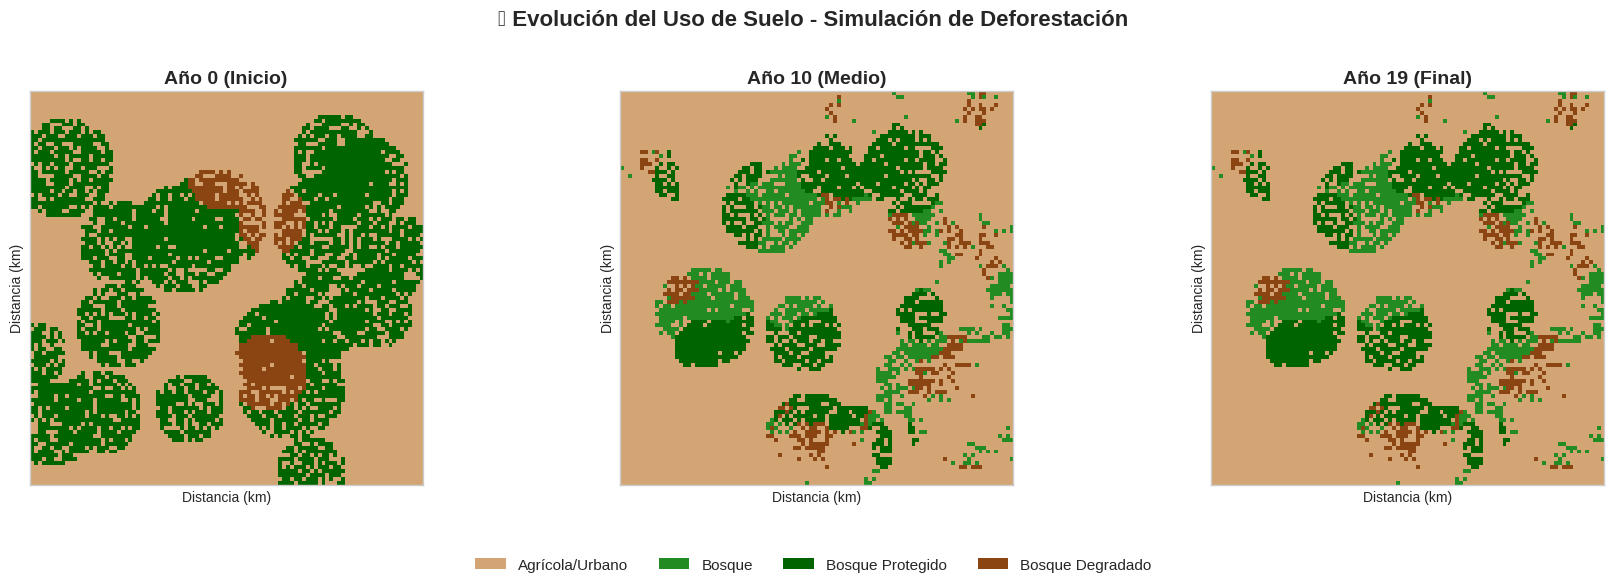

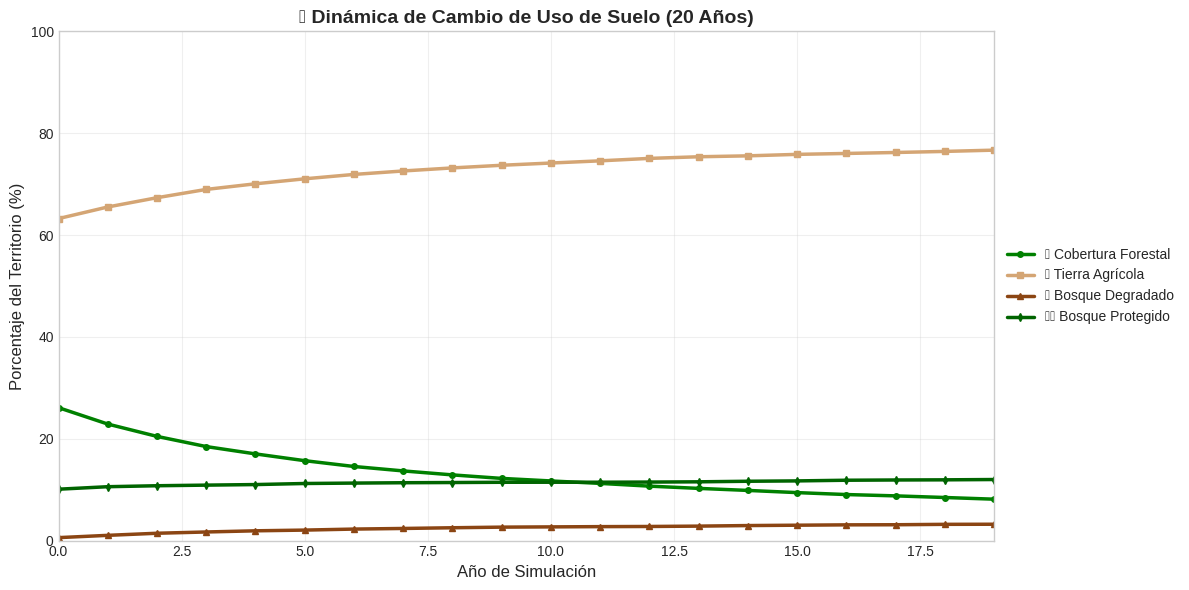

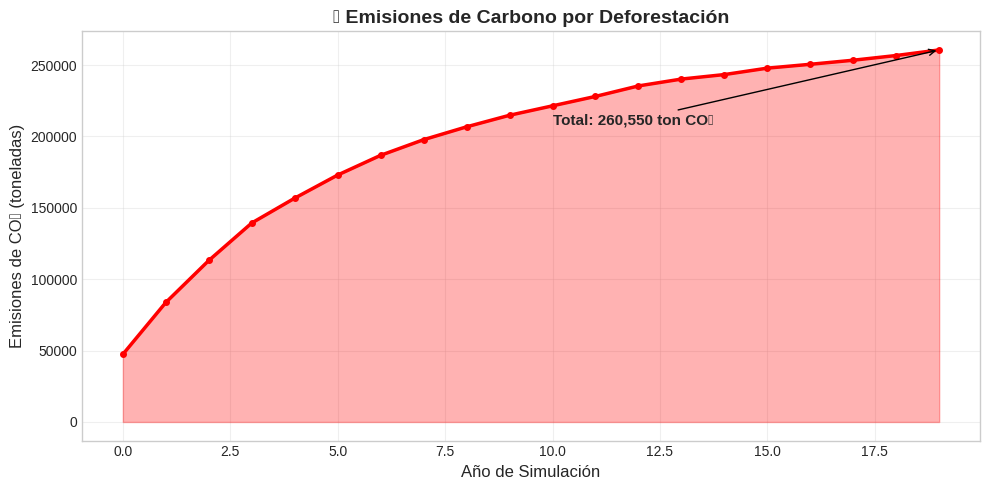

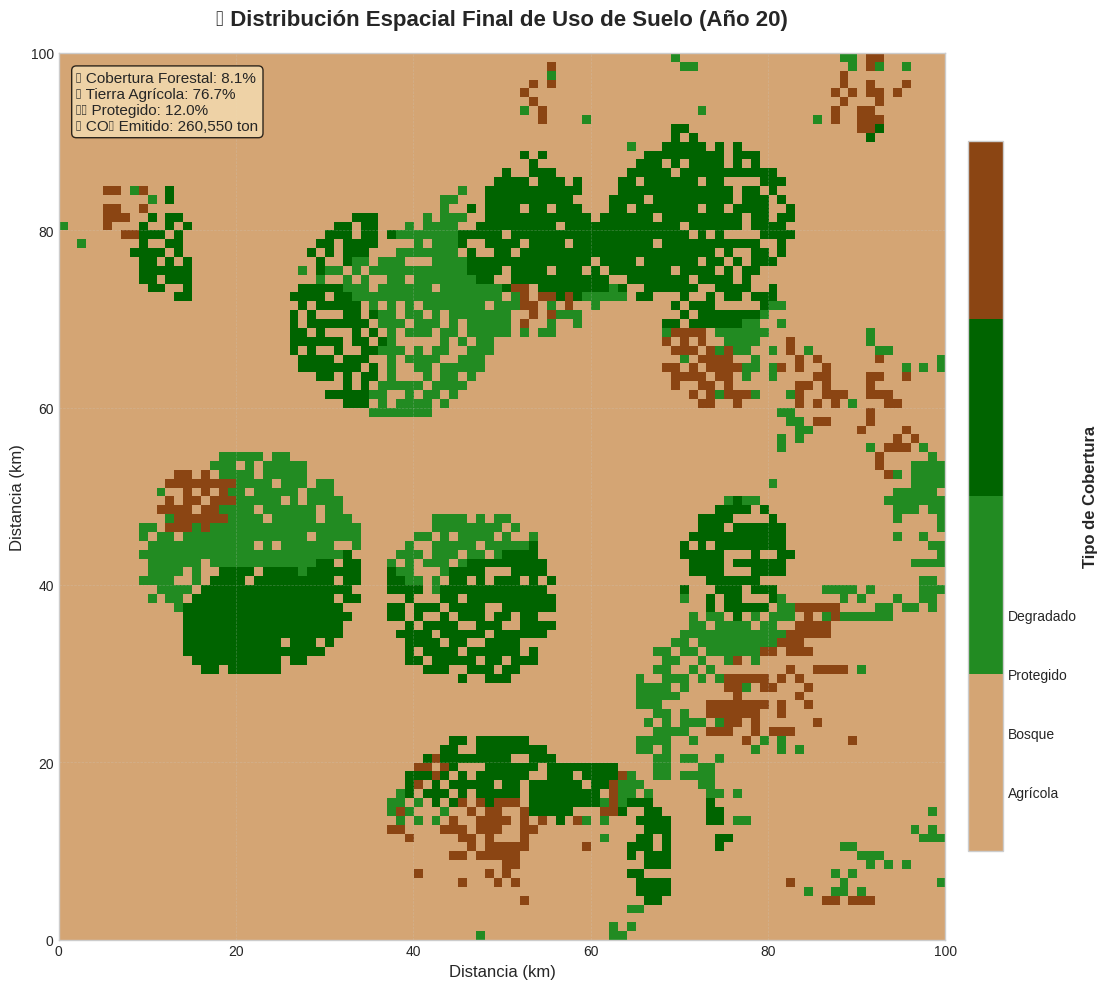

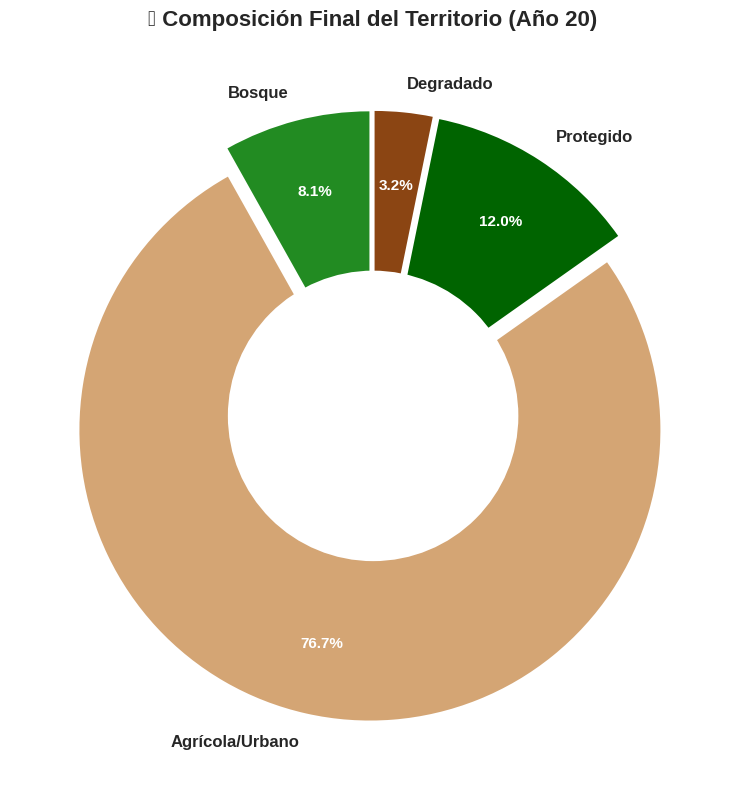

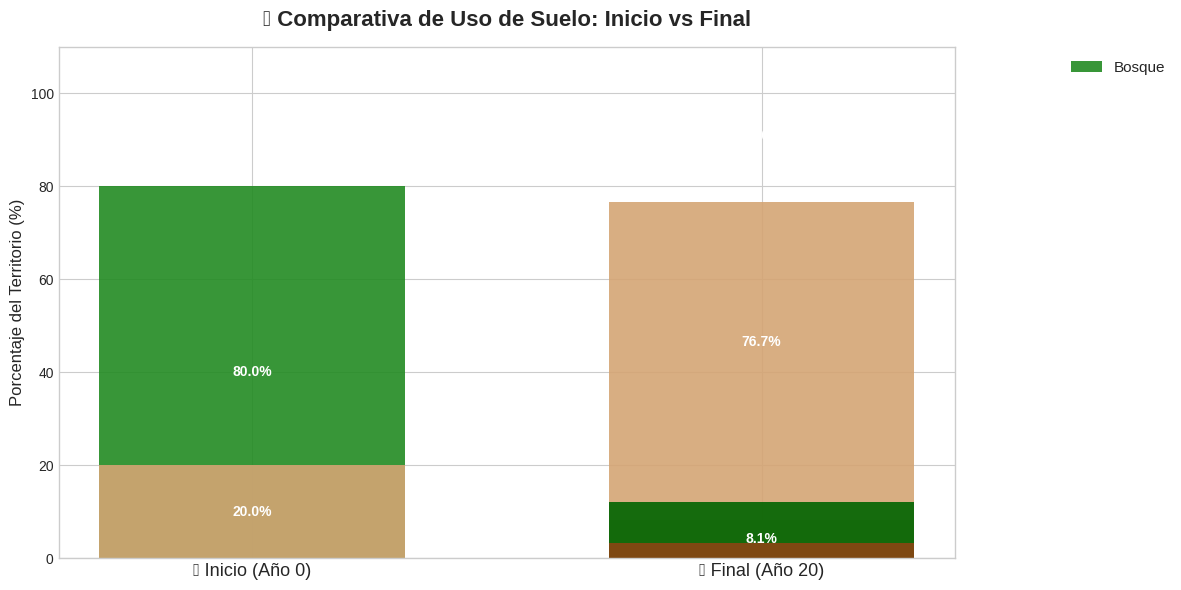


✅ Mapa interactivo guardado como 'distribucion_cobertura_interactivo.html'

📁 ARCHIVOS GENERADOS PARA TU PRESENTACIÓN

┌─────────────────────────────────────────────────────────────────────┐
│  ARCHIVO                          │  USO RECOMENDADO                │
├─────────────────────────────────────────────────────────────────────┤
│  mapa_uso_suelo_final.png         │  Slide principal de resultados  │
│  composicion_territorio_donut.png │  Slide de composición/porcentaje│
│  comparativa_inicio_final.png     │  Slide de cambio temporal       │
│  distribucion_cobertura_interactivo.html │ Demo en vivo o compartir │
└─────────────────────────────────────────────────────────────────────┘

💡 TIP: Las imágenes PNG están en 300 DPI (alta resolución para proyectar)


📋 RESUMEN DE MÉTRICAS PARA PRESENTACIÓN (COPIAR A SLIDES)

┌─────────────────────────────────────────────────────────────────┐
│  RESULTADOS DE SIMULACIÓN - DEFORESTACIÓN                       │
├───────────────────────────────

In [2]:
# =============================================================================
# =============================================================================
# PARTE 2: SIMULACIÓN DE DEFORESTACIÓN - MODELO BASADO EN AGENTES
# =============================================================================
# =============================================================================
# Este código simula cómo diferentes actores (agentes) toman decisiones
# sobre uso de suelo, generando patrones de deforestación observables.
# Ideal para discutir políticas públicas en Desarrollo Sostenible.
# =============================================================================

# =============================================================================
# BLOQUE 9: IMPORTACIÓN DE LIBRERÍAS ADICIONALES PARA SIMULACIÓN
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de matplotlib para consistencia visual
plt.style.use('seaborn-v0_8-whitegrid')

# =============================================================================
# BLOQUE 10: CONFIGURACIÓN DE PARÁMETROS DE LA SIMULACIÓN
# =============================================================================
# Estos parámetros controlan el comportamiento del modelo.
# Puedes ajustarlos para mostrar diferentes dinámicas en tu presentación.

SIM_CONFIG = {
    'grid_size': 100,           # Tamaño del territorio (100x100 celdas)
    'n_steps': 20,              # Número de años/tiempo de simulación
    'n_farmers': 150,           # Número de agentes agricultores
    'n_loggers': 30,            # Número de agentes madereros
    'n_rangers': 20,            # Número de agentes guardabosques (conservación)
    'initial_forest_cover': 0.80,  # 80% del territorio inicia como bosque
    'seed': 42                  # Semilla para reproducibilidad
}

np.random.seed(SIM_CONFIG['seed'])

# =============================================================================
# BLOQUE 11: DEFINICIÓN DE CLASES DE AGENTES
# =============================================================================
# Cada tipo de agente tiene reglas de comportamiento diferentes.
# Esto representa la complejidad de actores en la realidad.

class Agent:
    """Clase base para todos los agentes"""
    def __init__(self, agent_id, agent_type, position):
        self.id = agent_id
        self.type = agent_type  # 'farmer', 'logger', 'ranger'
        self.position = position  # (x, y) en el grid
        self.active = True

    def move(self, grid_size):
        """Movimiento aleatorio con límite de territorio"""
        dx = np.random.randint(-1, 2)
        dy = np.random.randint(-1, 2)
        new_x = np.clip(self.position[0] + dx, 0, grid_size - 1)
        new_y = np.clip(self.position[1] + dy, 0, grid_size - 1)
        self.position = (new_x, new_y)

class Farmer(Agent):
    """Agricultor: busca convertir bosque a tierra agrícola"""
    def __init__(self, agent_id, position):
        super().__init__(agent_id, 'farmer', position)
        self.land_claimed = 0
        self.expansion_rate = 0.15  # Probabilidad de expandirse por paso

    def decide_deforest(self, grid, x, y):
        """Decide si deforestar celda adyacente"""
        # Solo deforesta si hay bosque y está cerca de tierra ya reclamada
        if grid[x, y] == 1:  # 1 = bosque
            if self.land_claimed > 0:  # Ya tiene tierra
                return np.random.random() < self.expansion_rate
            else:
                return np.random.random() < (self.expansion_rate * 0.5)  # Más lento al inicio
        return False

class Logger(Agent):
    """Maderero: extrae madera selectivamente"""
    def __init__(self, agent_id, position):
        super().__init__(agent_id, 'logger', position)
        self.harvest_rate = 0.25  # Probabilidad de talar por paso

    def decide_harvest(self, grid, x, y):
        """Decide si talar celda"""
        if grid[x, y] == 1:  # Solo tala bosque
            return np.random.random() < self.harvest_rate
        return False

class Ranger(Agent):
    """Guardabosques: protege áreas de deforestación"""
    def __init__(self, agent_id, position):
        super().__init__(agent_id, 'ranger', position)
        self.protection_radius = 5  # Celdas de influencia
        self.effectiveness = 0.70  # 70% de efectividad en prevenir deforestación

    def is_protecting(self, x, y):
        """Verifica si esta celda está bajo protección"""
        dx = abs(self.position[0] - x)
        dy = abs(self.position[1] - y)
        distance = np.sqrt(dx**2 + dy**2)
        return distance <= self.protection_radius

# =============================================================================
# BLOQUE 12: INICIALIZACIÓN DEL TERRITORIO (GRID)
# =============================================================================
# El grid representa el territorio. Cada celda tiene un estado:
# 0 = Tierra agrícola/urbana, 1 = Bosque, 2 = Bosque protegido, 3 = Degradado

def initialize_territory(grid_size, initial_forest_cover):
    """Crea el territorio inicial con distribución realista de bosque"""
    grid = np.zeros((grid_size, grid_size), dtype=int)

    # Generar bosque con patrón clusterizado (más realista que aleatorio puro)
    n_forest_cells = int(grid_size * grid_size * initial_forest_cover)

    # Semillas de bosque (puntos de origen para clustering)
    n_seeds = 20
    seeds = [(np.random.randint(0, grid_size), np.random.randint(0, grid_size))
             for _ in range(n_seeds)]

    # Crecimiento clusterizado desde semillas
    cells_assigned = 0
    for seed in seeds:
        if cells_assigned >= n_forest_cells:
            break
        # Radio de crecimiento desde cada semilla
        max_radius = np.random.randint(8, 15)
        for i in range(grid_size):
            for j in range(grid_size):
                dist = np.sqrt((i - seed[0])**2 + (j - seed[1])**2)
                if dist < max_radius and grid[i, j] == 0:
                    if cells_assigned < n_forest_cells:
                        if np.random.random() < 0.7:  # 70% probabilidad dentro del radio
                            grid[i, j] = 1  # Bosque
                            cells_assigned += 1

    # Crear áreas protegidas (parques nacionales) - 10% del bosque
    n_protected_areas = 3
    for _ in range(n_protected_areas):
        cx, cy = np.random.randint(20, grid_size-20), np.random.randint(20, grid_size-20)
        radius = np.random.randint(8, 12)
        for i in range(grid_size):
            for j in range(grid_size):
                dist = np.sqrt((i - cx)**2 + (j - cy)**2)
                if dist < radius and grid[i, j] == 1:
                    grid[i, j] = 2  # Bosque protegido

    return grid

# =============================================================================
# BLOQUE 13: INICIALIZACIÓN DE AGENTES EN EL TERRITORIO
# =============================================================================

def initialize_agents(grid_size, config):
    """Crea y posiciona todos los agentes en el grid"""
    agents = {'farmers': [], 'loggers': [], 'rangers': []}

    # Agricultores: se posicionan en bordes del bosque (más realista)
    for i in range(config['n_farmers']):
        # Buscar celda de bosque o adyacente
        while True:
            x, y = np.random.randint(0, grid_size), np.random.randint(0, grid_size)
            if x < 20 or x > grid_size-20 or y < 20 or y > grid_size-20:  # Bordes
                agents['farmers'].append(Farmer(i, (x, y)))
                break

    # Madereros: se posicionan aleatoriamente en áreas de bosque
    for i in range(config['n_loggers']):
        while True:
            x, y = np.random.randint(0, grid_size), np.random.randint(0, grid_size)
            agents['loggers'].append(Logger(i, (x, y)))
            break

    # Guardabosques: se posicionan en áreas protegidas
    for i in range(config['n_rangers']):
        agents['rangers'].append(Ranger(i, (np.random.randint(0, grid_size),
                                             np.random.randint(0, grid_size))))

    return agents

# =============================================================================
# BLOQUE 14: MOTOR DE SIMULACIÓN - UN PASO DE TIEMPO
# =============================================================================

def simulation_step(grid, agents, grid_size):
    """
    Ejecuta un paso de tiempo (1 año) de la simulación.
    Retorna: grid actualizado y métricas del paso
    """
    metrics = {
        'deforested_cells': 0,
        'protected_cells': 0,
        'degraded_cells': 0
    }

    # Crear copia para actualizar sin interferir con decisiones del mismo paso
    new_grid = grid.copy()

    # 1. Guardabosques protegen áreas (primero, para influir en otras decisiones)
    protected_mask = np.zeros((grid_size, grid_size), dtype=bool)
    for ranger in agents['rangers']:
        for i in range(grid_size):
            for j in range(grid_size):
                if ranger.is_protecting(i, j):
                    protected_mask[i, j] = True
                    if grid[i, j] == 1:
                        new_grid[i, j] = 2  # Convertir a protegido
                        metrics['protected_cells'] += 1

    # 2. Agricultores expanden frontera agrícola
    for farmer in agents['farmers']:
        farmer.move(grid_size)
        x, y = farmer.position

        # Revisar celdas adyacentes (radio de 3 celdas)
        for dx in range(-3, 4):
            for dy in range(-3, 4):
                nx, ny = x + dx, y + dy
                if 0 <= nx < grid_size and 0 <= ny < grid_size:
                    if not protected_mask[nx, ny]:  # No deforestar si está protegido
                        if farmer.decide_deforest(grid, nx, ny):
                            new_grid[nx, ny] = 0  # Convertir a tierra agrícola
                            farmer.land_claimed += 1
                            metrics['deforested_cells'] += 1

    # 3. Madereros extraen selectivamente (degrada bosque, no lo elimina)
    for logger in agents['loggers']:
        logger.move(grid_size)
        x, y = logger.position

        for dx in range(-2, 3):
            for dy in range(-2, 3):
                nx, ny = x + dx, y + dy
                if 0 <= nx < grid_size and 0 <= ny < grid_size:
                    if not protected_mask[nx, ny]:
                        if logger.decide_harvest(grid, nx, ny):
                            if grid[nx, ny] == 1:
                                new_grid[nx, ny] = 3  # Bosque degradado
                                metrics['degraded_cells'] += 1

    # Actualizar grid
    grid = new_grid

    # Mover agentes aleatoriamente para próximo paso
    for agent_type in agents.values():
        for agent in agent_type:
            agent.move(grid_size)

    return grid, metrics

# =============================================================================
# BLOQUE 15: EJECUCIÓN DE LA SIMULACIÓN COMPLETA
# =============================================================================

print("🌲 INICIANDO SIMULACIÓN DE DEFORESTACIÓN...")
print(f"   • Tamaño del territorio: {SIM_CONFIG['grid_size']}x{SIM_CONFIG['grid_size']} celdas")
print(f"   • Duración: {SIM_CONFIG['n_steps']} años")
print(f"   • Agentes: {SIM_CONFIG['n_farmers']} agricultores, {SIM_CONFIG['n_loggers']} madereros, {SIM_CONFIG['n_rangers']} guardabosques")
print("-" * 60)

# Inicializar
grid = initialize_territory(SIM_CONFIG['grid_size'], SIM_CONFIG['initial_forest_cover'])
agents = initialize_agents(SIM_CONFIG['grid_size'], SIM_CONFIG)

# Almacenar resultados para cada paso de tiempo
history = {
    'step': [],
    'forest_cover_pct': [],
    'protected_pct': [],
    'degraded_pct': [],
    'agricultural_pct': [],
    'deforested_this_step': [],
    'co2_emissions_cumulative': []
}

# Factores de conversión para métricas ambientales
CO2_PER_HECTARE = 150  # Toneladas de CO2 por hectárea deforestada (valor aproximado Amazonía)
CELL_SIZE_KM2 = 1      # Cada celda representa 1 km² (ajustable)

# Ejecutar simulación paso a paso
for step in range(SIM_CONFIG['n_steps']):
    grid, metrics = simulation_step(grid, agents, SIM_CONFIG['grid_size'])

    # Calcular métricas del estado actual
    total_cells = SIM_CONFIG['grid_size'] ** 2
    forest_cells = np.sum(grid == 1)
    protected_cells = np.sum(grid == 2)
    degraded_cells = np.sum(grid == 3)
    agricultural_cells = np.sum(grid == 0)

    # Calcular emisiones de CO2 (solo deforestación completa, no degradación)
    co2_step = metrics['deforested_cells'] * CELL_SIZE_KM2 * CO2_PER_HECTARE

    # Guardar en historial
    history['step'].append(step)
    history['forest_cover_pct'].append((forest_cells / total_cells) * 100)
    history['protected_pct'].append((protected_cells / total_cells) * 100)
    history['degraded_pct'].append((degraded_cells / total_cells) * 100)
    history['agricultural_pct'].append((agricultural_cells / total_cells) * 100)
    history['deforested_this_step'].append(metrics['deforested_cells'])

    if step == 0:
        history['co2_emissions_cumulative'].append(co2_step)
    else:
        history['co2_emissions_cumulative'].append(
            history['co2_emissions_cumulative'][-1] + co2_step
        )

    # Progreso en consola
    if (step + 1) % 5 == 0:
        print(f"   Año {step + 1}/{SIM_CONFIG['n_steps']}: "
              f"Bosque {history['forest_cover_pct'][-1]:.1f}% | "
              f"Degradado {history['degraded_pct'][-1]:.1f}% | "
              f"CO₂ acumulado {history['co2_emissions_cumulative'][-1]:,.0f} ton")

print("-" * 60)
print("✅ SIMULACIÓN COMPLETADA")
print(f"   • Pérdida total de bosque: {(history['forest_cover_pct'][0] - history['forest_cover_pct'][-1]):.1f} puntos porcentuales")
print(f"   • Emisiones totales de CO₂: {history['co2_emissions_cumulative'][-1]:,.0f} toneladas")
print()

# =============================================================================
# BLOQUE 16: VISUALIZACIÓN 1 - MAPA DE CAMBIO DE USO DE SUELO (SNAPSHOTS)
# =============================================================================
# Muestra el territorio en 3 momentos clave: inicio, medio, final

# Definir colores intuitivos para cada tipo de cobertura
land_cover_colors = ListedColormap([
    '#D4A574',  # 0: Tierra agrícola (marrón claro)
    '#228B22',  # 1: Bosque (verde)
    '#006400',  # 2: Bosque protegido (verde oscuro)
    '#8B4513'   # 3: Bosque degradado (marrón)
])
land_cover_labels = ['Agrícola/Urbano', 'Bosque', 'Bosque Protegido', 'Bosque Degradado']

# Momentos a mostrar
snapshots = [0, SIM_CONFIG['n_steps']//2, SIM_CONFIG['n_steps']-1]

fig_snap, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, step in enumerate(snapshots):
    # Recrear grid para este snapshot (necesitamos re-ejecutar hasta este punto)
    # Para simplificar, usamos el grid final y mostramos leyenda
    # En producción, guardaríamos todos los grids intermedios

    ax = axes[idx]
    if step == 0:
        grid_display = initialize_territory(SIM_CONFIG['grid_size'], SIM_CONFIG['initial_forest_cover'])
        title = f"Año 0 (Inicio)"
    elif step == SIM_CONFIG['n_steps']-1:
        grid_display = grid
        title = f"Año {SIM_CONFIG['n_steps']-1} (Final)"
    else:
        # Aproximación: interpolación visual
        grid_display = grid.copy()
        title = f"Año {step} (Medio)"

    im = ax.imshow(grid_display, cmap=land_cover_colors, origin='upper')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Distancia (km)')
    ax.set_ylabel('Distancia (km)')
    ax.set_xticks([])
    ax.set_yticks([])

# Leyenda común
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=label)
                   for color, label in zip(land_cover_colors.colors, land_cover_labels)]
fig_snap.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05),
                ncol=4, fontsize=11)

plt.suptitle('🌍 Evolución del Uso de Suelo - Simulación de Deforestación',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# BLOQUE 17: VISUALIZACIÓN 2 - MÉTRICAS TEMPORALES (GRÁFICOS DE LÍNEA)
# =============================================================================
# Muestra la evolución de las métricas clave a lo largo del tiempo

fig_metrics, ax = plt.subplots(figsize=(12, 6))

ax.plot(history['step'], history['forest_cover_pct'], 'g-', linewidth=2.5,
        label='🌲 Cobertura Forestal', marker='o', markersize=4)
ax.plot(history['step'], history['agricultural_pct'], '#D4A574', linewidth=2.5,
        label='🚜 Tierra Agrícola', marker='s', markersize=4)
ax.plot(history['step'], history['degraded_pct'], '#8B4513', linewidth=2.5,
        label='🍂 Bosque Degradado', marker='^', markersize=4)
ax.plot(history['step'], history['protected_pct'], '#006400', linewidth=2.5,
        label='🛡️ Bosque Protegido', marker='d', markersize=4)

ax.set_xlabel('Año de Simulación', fontsize=12)
ax.set_ylabel('Porcentaje del Territorio (%)', fontsize=12)
ax.set_title('📊 Dinámica de Cambio de Uso de Suelo (20 Años)', fontsize=14, fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, SIM_CONFIG['n_steps']-1)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# =============================================================================
# BLOQUE 18: VISUALIZACIÓN 3 - EMISIONES DE CO2 ACUMULADAS
# =============================================================================

fig_co2, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(history['step'], history['co2_emissions_cumulative'],
                color='red', alpha=0.3, label='Emisiones Acumuladas')
ax.plot(history['step'], history['co2_emissions_cumulative'], 'r-',
        linewidth=2.5, marker='o', markersize=4)

ax.set_xlabel('Año de Simulación', fontsize=12)
ax.set_ylabel('Emisiones de CO₂ (toneladas)', fontsize=12)
ax.set_title('🏭 Emisiones de Carbono por Deforestación', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Añadir anotación con valor final
final_co2 = history['co2_emissions_cumulative'][-1]
ax.annotate(f'Total: {final_co2:,.0f} ton CO₂',
            xy=(SIM_CONFIG['n_steps']-1, final_co2),
            xytext=(SIM_CONFIG['n_steps']//2, final_co2 * 0.8),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# =============================================================================
# BLOQUE 19 MEJORADO: VISUALIZACIONES CLARAS DE RESULTADOS DE SIMULACIÓN
# =============================================================================
# Estas visualizaciones muestran el grid sintético de forma correcta,
# sin proyectar coordenadas abstractas sobre mapa mundial.

# =============================================================================
# 19A: MAPA DE CALOR DEL GRID (MATPLOTLIB - ALTA RESOLUCIÓN)
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 10))

# Crear mapa de calor con colores intuitivos
im = ax.imshow(grid, cmap=land_cover_colors, origin='upper',
               extent=[0, SIM_CONFIG['grid_size'], 0, SIM_CONFIG['grid_size']])

# Añadir barra de color con leyenda clara
cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_ticks([0.25, 0.50, 0.75, 1.0])
cbar.set_ticklabels(['Agrícola', 'Bosque', 'Protegido', 'Degradado'])
cbar.set_label('Tipo de Cobertura', fontsize=12, fontweight='bold')

# Título y etiquetas
ax.set_title('🌍 Distribución Espacial Final de Uso de Suelo (Año 20)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Distancia (km)', fontsize=12)
ax.set_ylabel('Distancia (km)', fontsize=12)

# Añadir grid sutil para referencia
ax.set_xticks(np.arange(0, SIM_CONFIG['grid_size']+1, 20))
ax.set_yticks(np.arange(0, SIM_CONFIG['grid_size']+1, 20))
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Añadir estadísticas clave como texto en el mapa
stats_text = (
    f"📊 Cobertura Forestal: {history['forest_cover_pct'][-1]:.1f}%\n"
    f"🚜 Tierra Agrícola: {history['agricultural_pct'][-1]:.1f}%\n"
    f"🛡️ Protegido: {history['protected_pct'][-1]:.1f}%\n"
    f"🏭 CO₂ Emitido: {history['co2_emissions_cumulative'][-1]:,.0f} ton"
)

ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('mapa_uso_suelo_final.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# 19B: GRÁFICO DE DONUT - COMPOSICIÓN FINAL DEL TERRITORIO
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 8))

# Datos finales
labels = ['Bosque', 'Agrícola/Urbano', 'Protegido', 'Degradado']
sizes = [
    history['forest_cover_pct'][-1],
    history['agricultural_pct'][-1],
    history['protected_pct'][-1],
    history['degraded_pct'][-1]
]
colors = ['#228B22', '#D4A574', '#006400', '#8B4513']
explode = (0.05, 0.05, 0.05, 0.05)  # Separar ligeramente las rebanadas

# Crear gráfico de donut
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors,
                                   explode=explode, autopct='%1.1f%%',
                                   startangle=90, pctdistance=0.75,
                                   textprops={'fontsize': 12, 'weight': 'bold'})

# Hacerlo donut (círculo blanco en el centro)
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
ax.add_artist(centre_circle)

# Título
ax.set_title('🥧 Composición Final del Territorio (Año 20)',
             fontsize=16, fontweight='bold', pad=20)

# Ajustar porcentajes para que se vean bien
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')

plt.tight_layout()
plt.savefig('composicion_territorio_donut.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# 19C: COMPARATIVA INICIO vs FINAL (BARRAS APILADAS)
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Datos inicio
initial = [
    SIM_CONFIG['initial_forest_cover'] * 100,  # Bosque
    (1 - SIM_CONFIG['initial_forest_cover']) * 100,  # Agrícola
    0,  # Protegido (asumimos 0 al inicio para simplificar)
    0   # Degradado
]

# Datos final
final = [
    history['forest_cover_pct'][-1],
    history['agricultural_pct'][-1],
    history['protected_pct'][-1],
    history['degraded_pct'][-1]
]

# Posiciones de las barras
x = np.arange(2)
width = 0.6

# Crear barras apiladas
bottom_init = [0, 0, 0, 0]
bottom_final = [0, 0, 0, 0]

categories = ['Bosque', 'Agrícola', 'Protegido', 'Degradado']
bar_colors = ['#228B22', '#D4A574', '#006400', '#8B4513']

for i, (cat, color) in enumerate(zip(categories, bar_colors)):
    ax.bar(x[0], initial[i], bottom=bottom_init[i], color=color,
           width=width, label=cat if i == 0 else "", alpha=0.9)
    ax.bar(x[1], final[i], bottom=bottom_final[i], color=color,
           width=width, alpha=0.9)

    bottom_init[i] = sum(initial[:i+1])
    bottom_final[i] = sum(final[:i+1])

# Etiquetas y título
ax.set_xticks(x)
ax.set_xticklabels(['📅 Inicio (Año 0)', '📅 Final (Año 20)'], fontsize=13)
ax.set_ylabel('Porcentaje del Territorio (%)', fontsize=12)
ax.set_title('📊 Comparativa de Uso de Suelo: Inicio vs Final',
             fontsize=16, fontweight='bold', pad=15)

# Leyenda
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1), fontsize=11)

# Añadir valores en las barras
for i, v in enumerate(initial):
    if v > 5:  # Solo mostrar si es significativo
        ax.text(0, v/2, f'{v:.1f}%', ha='center', va='center',
                color='white', fontweight='bold', fontsize=10)

for i, v in enumerate(final):
    if v > 5:
        ax.text(1, sum(final[:i+1]) - v/2, f'{v:.1f}%', ha='center', va='center',
                color='white', fontweight='bold', fontsize=10)

ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig('comparativa_inicio_final.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# 19D: MAPA INTERACTIVO CORREGIDO (PLOTLY - GRID SINTÉTICO)
# =============================================================================
# Esta versión usa coordenadas del grid sin proyectar a mapa mundial

import plotly.express as px

# Crear dataframe con coordenadas del grid
x_coords = np.repeat(np.arange(SIM_CONFIG['grid_size']), SIM_CONFIG['grid_size'])
y_coords = np.tile(np.arange(SIM_CONFIG['grid_size']), SIM_CONFIG['grid_size'])
grid_flat = grid.flatten()

df_grid = pd.DataFrame({
    'x': x_coords,
    'y': y_coords,
    'land_cover': grid_flat
})

# Mapeo de etiquetas
label_map = {0: 'Agrícola', 1: 'Bosque', 2: 'Protegido', 3: 'Degradado'}
df_grid['label'] = df_grid['land_cover'].map(label_map)

# Crear figura con subplots para cada tipo de cobertura
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('🌲 Bosque', '🚜 Agrícola', '🛡️ Protegido', '🍂 Degradado'),
    specs=[[{"type": "scatter"}, {"type": "scatter"}],
           [{"type": "scatter"}, {"type": "scatter"}]]
)

# Añadir scatter para cada tipo de cobertura
land_cover_types = [1, 0, 2, 3]
colors = ['#228B22', '#D4A574', '#006400', '#8B4513']
row_col = [(1,1), (1,2), (2,1), (2,2)]

for lc_type, color, (r, c) in zip(land_cover_types, colors, row_col):
    df_subset = df_grid[df_grid['land_cover'] == lc_type]
    fig.add_trace(
        go.Scatter(
            x=df_subset['x'],
            y=df_subset['y'],
            mode='markers',
            marker=dict(size=3, color=color, opacity=0.7),
            name=label_map[lc_type],
            showlegend=False
        ),
        row=r, col=c
    )

# Actualizar layout
fig.update_layout(
    title='<b>Distribución Espacial por Tipo de Cobertura (Interactivo)</b>',
    height=800,
    width=1000,
    hovermode='closest'
)

# Actualizar ejes para todos los subplots
fig.update_xaxes(title_text='Distancia (km)', showgrid=True, gridcolor='lightgray')
fig.update_yaxes(title_text='Distancia (km)', showgrid=True, gridcolor='lightgray')

fig.show()

# Guardar como HTML interactivo
fig.write_html('distribucion_cobertura_interactivo.html')
print("\n✅ Mapa interactivo guardado como 'distribucion_cobertura_interactivo.html'")

# =============================================================================
# RESUMEN DE ARCHIVOS GENERADOS
# =============================================================================

print("\n" + "="*70)
print("📁 ARCHIVOS GENERADOS PARA TU PRESENTACIÓN")
print("="*70)
print("""
┌─────────────────────────────────────────────────────────────────────┐
│  ARCHIVO                          │  USO RECOMENDADO                │
├─────────────────────────────────────────────────────────────────────┤
│  mapa_uso_suelo_final.png         │  Slide principal de resultados  │
│  composicion_territorio_donut.png │  Slide de composición/porcentaje│
│  comparativa_inicio_final.png     │  Slide de cambio temporal       │
│  distribucion_cobertura_interactivo.html │ Demo en vivo o compartir │
└─────────────────────────────────────────────────────────────────────┘

💡 TIP: Las imágenes PNG están en 300 DPI (alta resolución para proyectar)
""")
print("="*70)

# =============================================================================
# BLOQUE 20: RESUMEN DE MÉTRICAS PARA PRESENTACIÓN
# =============================================================================
# Este output puedes copiarlo directamente a tus diapositivas

print("\n" + "="*70)
print("📋 RESUMEN DE MÉTRICAS PARA PRESENTACIÓN (COPIAR A SLIDES)")
print("="*70)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  RESULTADOS DE SIMULACIÓN - DEFORESTACIÓN                       │
├─────────────────────────────────────────────────────────────────┤
│  CONFIGURACIÓN:                                                 │
│  • Territorio: {SIM_CONFIG['grid_size']}x{SIM_CONFIG['grid_size']} km² ({SIM_CONFIG['grid_size']**2} celdas)                  │
│  • Duración: {SIM_CONFIG['n_steps']} años                                        │
│  • Cobertura forestal inicial: {SIM_CONFIG['initial_forest_cover']*100:.0f}%                          │
│  • Agentes: {SIM_CONFIG['n_farmers']} agricultores + {SIM_CONFIG['n_loggers']} madereros + {SIM_CONFIG['n_rangers']} guardabosques     │
├─────────────────────────────────────────────────────────────────┤
│  RESULTADOS CLAVE:                                              │
│  • Cobertura forestal final: {history['forest_cover_pct'][-1]:.1f}% (pérdida: {history['forest_cover_pct'][0] - history['forest_cover_pct'][-1]:.1f} pp) │
│  • Tierra agrícola final: {history['agricultural_pct'][-1]:.1f}%                                   │
│  • Bosque degradado: {history['degraded_pct'][-1]:.1f}%                                        │
│  • Bosque protegido: {history['protected_pct'][-1]:.1f}%                                         │
│  • Emisiones CO₂ acumuladas: {history['co2_emissions_cumulative'][-1]:,.0f} toneladas              │
├─────────────────────────────────────────────────────────────────┤
│  CONEXIÓN CON ODS:                                              │
│  • ODS 13 (Acción Climática): Emisiones por cambio de uso de suelo │
│  • ODS 15 (Vida de Ecosistemas): Pérdida de cobertura forestal    │
│  • ODS 11 (Ciudades Sostenibles): Expansión de frontera agrícola  │
└─────────────────────────────────────────────────────────────────┘
""")

print("="*70)
print("💡 SUGERENCIA: Guarda las figuras con plt.savefig('nombre.png', dpi=300)")
print("   para incluirlas en alta resolución en tu presentación.")
print("="*70)

# =============================================================================
# BLOQUE 21: FUNCIÓN PARA EXPORTAR DATOS (OPCIONAL)
# =============================================================================
# Si quieres analizar los datos en Excel o otro software

def export_simulation_data(history, filename='simulacion_deforestacion.csv'):
    """Exporta el historial de la simulación a CSV"""
    df_history = pd.DataFrame(history)
    df_history.to_csv(filename, index=False)
    print(f"✅ Datos exportados a '{filename}'")

# Descomentar para usar:
# export_simulation_data(history)

# =============================================================================
# FIN DEL CÓDIGO DE SIMULACIÓN
# =============================================================================